In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [96]:
df_org= pd.read_csv('Traffic_Data_Gov.csv')
df = df_org.copy()
print(df.shape)
df.columns.tolist()

(273913, 27)


C:\Users\vilas\AppData\Local\Temp\ipykernel_20188\979764693.py:1: DtypeWarning: Columns (16,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df_org= pd.read_csv('Traffic_Data_Gov.csv')


['the_geom',
 'cartodb_id',
 'the_geom_webmercator',
 'record_id',
 'station_key',
 'station_id',
 'traffic_direction_seq',
 'traffic_direction_name',
 'cardinal_direction_seq',
 'cardinal_direction_name',
 'classification_seq',
 'classification_type',
 'count_type',
 'year',
 'period',
 'partial_year',
 'latest_date',
 'traffic_count',
 'data_start_date',
 'data_end_date',
 'data_duration',
 'data_availability',
 'data_reliability',
 'data_quality_indicator',
 'publish',
 'md5',
 'updated_on']

In [97]:
df.isnull().sum()

the_geom                   273913
cartodb_id                      0
the_geom_webmercator       273913
record_id                  273913
station_key                     0
station_id                      0
traffic_direction_seq           0
traffic_direction_name          0
cardinal_direction_seq          0
cardinal_direction_name         0
classification_seq              0
classification_type             0
count_type                      0
year                            0
period                          0
partial_year                    0
latest_date                260590
traffic_count                   0
data_start_date            207663
data_end_date              207663
data_duration              207663
data_availability               0
data_reliability                0
data_quality_indicator          0
publish                         0
md5                             0
updated_on                 153072
dtype: int64

✅ Columns WITH missing values : 8
✅ Columns with NO missing     : 19


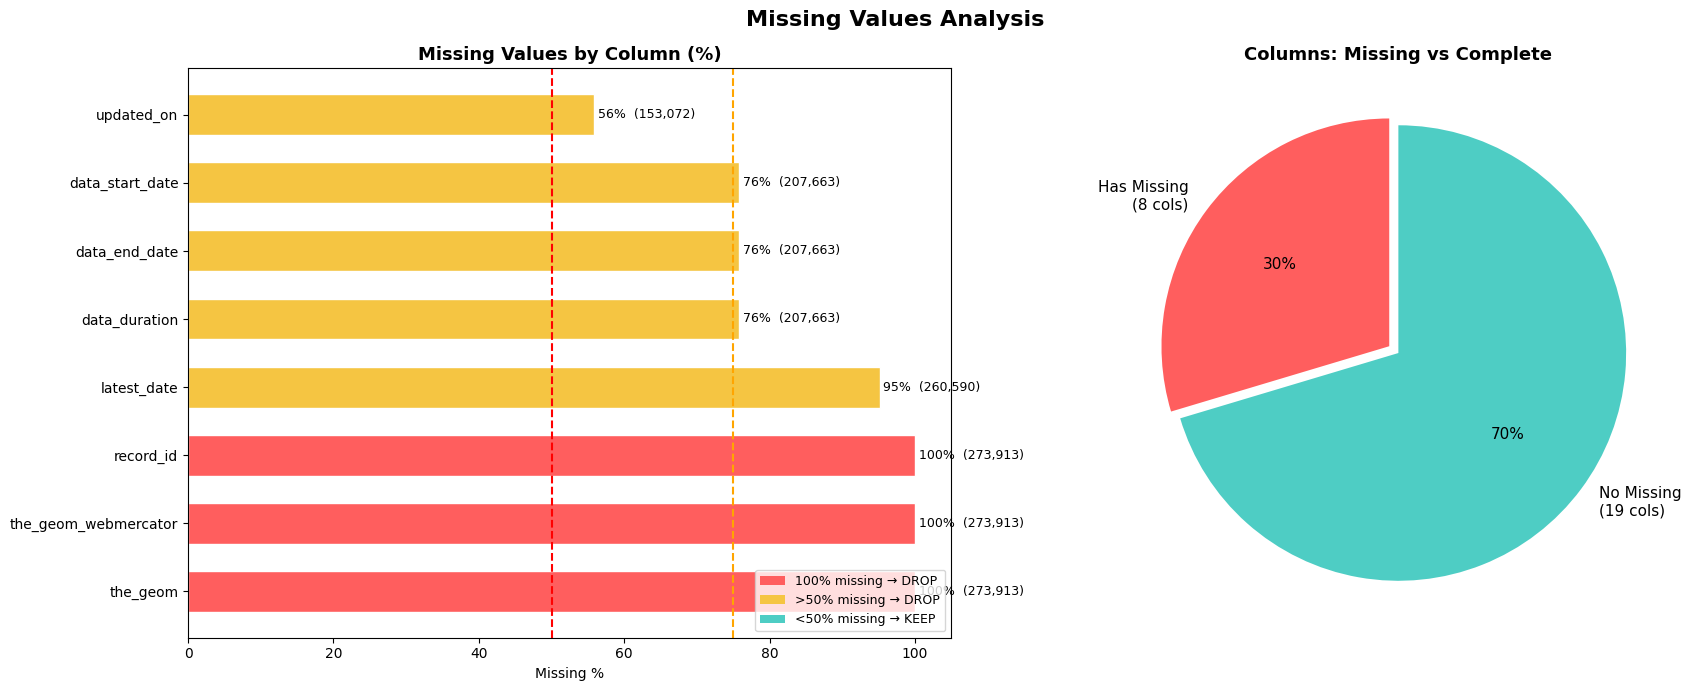

In [98]:
# ─────────────────────────────────────────
# VISUALIZE MISSING VALUES
# ─────────────────────────────────────────

missing      = df.isnull().sum()
missing_pct  = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %'     : missing_pct
}).sort_values('Missing %', ascending=False)

# Split into has missing vs no missing
has_missing = missing_df[missing_df['Missing %'] > 0]
no_missing  = missing_df[missing_df['Missing %'] == 0]

print(f"✅ Columns WITH missing values : {len(has_missing)}")
print(f"✅ Columns with NO missing     : {len(no_missing)}")

# ── Plot ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Missing Values Analysis', 
             fontsize=16, fontweight='bold')

# Chart 1: Missing % bar chart
colors = ['#ff5e5e' if x == 100 
          else '#f5c542' if x > 50 
          else '#4ecdc4' 
          for x in has_missing['Missing %']]

bars = axes[0].barh(has_missing.index, 
                     has_missing['Missing %'],
                     color=colors, 
                     edgecolor='white',
                     height=0.6)

axes[0].set_title('Missing Values by Column (%)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Missing %')
axes[0].axvline(x=50, color='red', 
                linestyle='--', linewidth=1.5,
                label='50% threshold')
axes[0].axvline(x=75, color='orange',
                linestyle='--', linewidth=1.5,
                label='75% threshold')
axes[0].legend()

# Add value labels
for bar, val, count in zip(bars, 
                            has_missing['Missing %'],
                            has_missing['Missing Count']):
    axes[0].text(val + 0.5,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.0f}%  ({count:,})',
                 va='center', fontsize=9)

# Chart 2: Missing vs Not Missing pie
sizes  = [len(has_missing), len(no_missing)]
labels = [f'Has Missing\n({len(has_missing)} cols)',
          f'No Missing\n({len(no_missing)} cols)']
colors_pie = ['#ff5e5e', '#4ecdc4']
explode    = (0.05, 0)

axes[1].pie(sizes, labels=labels,
            colors=colors_pie,
            explode=explode,
            autopct='%1.0f%%',
            startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Columns: Missing vs Complete',
                   fontsize=13, fontweight='bold')

# Legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#ff5e5e', label='100% missing → DROP'),
    Patch(facecolor='#f5c542', label='>50% missing → DROP'),
    Patch(facecolor='#4ecdc4', label='<50% missing → KEEP'),
]
axes[0].legend(handles=legend_elements, 
               loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('missing_values.png', 
            dpi=150, bbox_inches='tight')
plt.show()

In [99]:
df.describe

<bound method NDFrame.describe of         the_geom  cartodb_id  the_geom_webmercator  record_id  station_key  \
0            NaN      670946                   NaN        NaN        55318   
1            NaN      670947                   NaN        NaN     15252005   
2            NaN      670948                   NaN        NaN        57462   
3            NaN      670949                   NaN        NaN        58875   
4            NaN      670950                   NaN        NaN        56892   
...          ...         ...                   ...        ...          ...   
273908       NaN      985114                   NaN        NaN     74998002   
273909       NaN      985151                   NaN        NaN     15828018   
273910       NaN      985183                   NaN        NaN     15175635   
273911       NaN      985184                   NaN        NaN     74612001   
273912       NaN      985186                   NaN        NaN     74886000   

       station_id  traffic_di

In [100]:
df

,the_geom,cartodb_id,the_geom_webmercator,record_id,station_key,station_id,traffic_direction_seq,traffic_direction_name,cardinal_direction_seq,cardinal_direction_name,...,traffic_count,data_start_date,data_end_date,data_duration,data_availability,data_reliability,data_quality_indicator,publish,md5,updated_on
0,NaN,670946,NaN,NaN,55318,02015,2,PRESCRIBED AND COUNTER,9,BOTH,...,39273,NaN,NaN,NaN,-1,-1,0,1,2c3a9b9bf222b4b98d5da5b20455e378,2018-12-14 05:33:24.64657+00
1,NaN,670947,NaN,NaN,15252005,6157,0,COUNTER,5,SOUTH,...,705,NaN,NaN,NaN,1,92,0,1,80c733285025af031a4fffaa89f004db,2022-02-04 09:44:28.431958+00
2,NaN,670948,NaN,NaN,57462,83011,0,COUNTER,5,SOUTH,...,1722,NaN,NaN,NaN,10,77,0,1,f93f7c9eb82be6744ae1fd7b2716ef55,2020-09-03 01:24:31.45111+00
3,NaN,670949,NaN,NaN,58875,F3FWY006,2,PRESCRIBED AND COUNTER,9,BOTH,...,2178,NaN,NaN,NaN,-1,-1,0,1,b5cc8afd807d718fa40f2b7872458136,2018-07-09 03:45:51.087472+00
4,NaN,670950,NaN,NaN,56892,34029,0,COUNTER,5,SOUTH,...,7541,NaN,NaN,NaN,-1,-1,0,1,eb6c56f804a90c58d627524cd313fed5,2018-01-09 22:39:10.806238+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273908,NaN,985114,NaN,NaN,74998002,T6189W,2,PRESCRIBED AND COUNTER,10,BOTH,...,1926,NaN,NaN,NaN,-1,-1,0,1,FF4A35C1E97FE966C7265A04BDE5144E,2025-12-04 10:09:31.918354+00
273909,NaN,985151,NaN,NaN,15828018,T0494,2,PRESCRIBED AND COUNTER,9,BOTH,...,236,NaN,NaN,NaN,-1,-1,0,1,CBF7A742B603DA8C817FEBC4373069BF,2025-12-04 10:09:31.918354+00
273910,NaN,985183,NaN,NaN,15175635,6124,2,PRESCRIBED AND COUNTER,9,BOTH,...,325,NaN,NaN,NaN,-1,-1,0,1,77839AE7CB587FA75A3A2DD09AB9E826,2025-12-04 10:09:31.918354+00
273911,NaN,985184,NaN,NaN,74612001,T6132W,0,COUNTER,3,EAST,...,192,NaN,NaN,NaN,-1,-1,0,1,5648DE5F3000CDBA295569F32B8A2F78,2025-12-04 10:09:31.918354+00


In [101]:
# ─────────────────────────────────────────
# DROP USELESS COLUMNS
# ─────────────────────────────────────────

cols_to_drop = [
    # 100% empty
    'the_geom',
    'the_geom_webmercator',
    'record_id',

    # 95%+ missing
    'latest_date',
    'data_start_date',
    'data_end_date',
    'data_duration',

    # 56% missing - just admin timestamp
    'updated_on',

    # System columns - no ML value
    'md5',
    'cartodb_id',

    # Always same value - no variation
    'count_type',           # always TRAFFIC COUNT
    'publish',              # always 1
    'data_quality_indicator' # always 0
]

df.drop(columns=cols_to_drop, inplace=True)

print(f"✅ Dropped {len(cols_to_drop)} columns")
print(f"✅ Columns remaining: {df.shape[1]}")
print(f"\nRemaining columns:")
for col in df.columns:
    print(f"   ✅ {col}")

✅ Dropped 13 columns
✅ Columns remaining: 14

Remaining columns:
   ✅ station_key
   ✅ station_id
   ✅ traffic_direction_seq
   ✅ traffic_direction_name
   ✅ cardinal_direction_seq
   ✅ cardinal_direction_name
   ✅ classification_seq
   ✅ classification_type
   ✅ year
   ✅ period
   ✅ partial_year
   ✅ traffic_count
   ✅ data_availability
   ✅ data_reliability


In [102]:
print("NUMERIC COLUMNS")
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    print(f"\n{col}")
    print(f"  Min    : {df[col].min()}")
    print(f"  Max    : {df[col].max()}")
    print(f"  Mean   : {df[col].mean():.2f}")
    print(f"  Nulls  : {df[col].isnull().sum()}")
    # Show unique if small number of values
    if df[col].nunique() <= 10:
        print(f"  Unique : {sorted(df[col].unique())}")

print("\n" + "=" * 55)
print("CATEGORICAL COLUMNS")
print("=" * 55)
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n{col}")
    print(f"  Unique values: {df[col].nunique()}")
    print(df[col].value_counts())

print("\n" + "=" * 55)
print("BOOLEAN COLUMNS")
print("=" * 55)
bool_cols = df.select_dtypes(include='bool').columns
for col in bool_cols:
    print(f"\n{col}")
    print(df[col].value_counts())

NUMERIC COLUMNS

station_key
  Min    : -1
  Max    : 99990015
  Mean   : 10630487.62
  Nulls  : 0

traffic_direction_seq
  Min    : 0
  Max    : 2
  Mean   : 0.95
  Nulls  : 0
  Unique : [0, 1, 2]

cardinal_direction_seq
  Min    : 1
  Max    : 10
  Mean   : 5.45
  Nulls  : 0
  Unique : [1, 3, 5, 7, 9, 10]

classification_seq
  Min    : 0
  Max    : 3
  Mean   : 1.44
  Nulls  : 0
  Unique : [0, 1, 2, 3]

year
  Min    : 2006
  Max    : 2026
  Mean   : 2015.19
  Nulls  : 0

traffic_count
  Min    : 1
  Max    : 183074
  Mean   : 7699.56
  Nulls  : 0

data_availability
  Min    : -1
  Max    : 100
  Mean   : 14.23
  Nulls  : 0

data_reliability
  Min    : -1
  Max    : 100
  Mean   : 31.30
  Nulls  : 0

CATEGORICAL COLUMNS

station_id
  Unique values: 1967
station_id
50260       1137
74228       1134
29005       1134
72027       1133
F3FWY001    1115
            ... 
08320          6
95679          6
02376          6
83013          5
07297          2
Name: count, Length: 1967, dtype: in

In [103]:
df['data_availability'].replace(-1, np.nan, inplace=True)
df['data_reliability'].replace(-1, np.nan,  inplace=True)
df['data_availability'].fillna(df['data_availability'].median(), inplace=True)
df['data_reliability'].fillna(df['data_reliability'].median(),   inplace=True)

C:\Users\vilas\AppData\Local\Temp\ipykernel_20188\2943791188.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['data_availability'].replace(-1, np.nan, inplace=True)
C:\Users\vilas\AppData\Local\Temp\ipykernel_20188\2943791188.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

In [104]:
df.drop(df[df['year'] == 2026].index, inplace=True)
df.drop(df[df['period']=='SCHOOL HOLIDAYS'].index,inplace=True)

In [105]:
print(df['year'].sort_values().unique())
print(df['period'].sort_values().unique())


[2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019
 2020 2021 2022 2023 2024 2025]
['ALL DAYS' 'AM PEAK' 'OFF PEAK' 'PM PEAK' 'PUBLIC HOLIDAYS' 'WEEKDAYS'
 'WEEKENDS']


In [106]:
df

,station_key,station_id,traffic_direction_seq,traffic_direction_name,cardinal_direction_seq,cardinal_direction_name,classification_seq,classification_type,year,period,partial_year,traffic_count,data_availability,data_reliability
0,55318,02015,2,PRESCRIBED AND COUNTER,9,BOTH,0,UNCLASSIFIED,2018,WEEKDAYS,False,39273,37.0,93.0
1,15252005,6157,0,COUNTER,5,SOUTH,3,HEAVY VEHICLES,2022,ALL DAYS,False,705,1.0,92.0
2,57462,83011,0,COUNTER,5,SOUTH,3,HEAVY VEHICLES,2020,ALL DAYS,False,1722,10.0,77.0
3,58875,F3FWY006,2,PRESCRIBED AND COUNTER,9,BOTH,3,HEAVY VEHICLES,2018,PM PEAK,False,2178,37.0,93.0
4,56892,34029,0,COUNTER,5,SOUTH,0,UNCLASSIFIED,2016,WEEKDAYS,True,7541,37.0,93.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273908,74998002,T6189W,2,PRESCRIBED AND COUNTER,10,BOTH,2,LIGHT VEHICLES,2025,AM PEAK,False,1926,37.0,93.0
273909,15828018,T0494,2,PRESCRIBED AND COUNTER,9,BOTH,1,ALL VEHICLES,2025,WEEKENDS,False,236,37.0,93.0
273910,15175635,6124,2,PRESCRIBED AND COUNTER,9,BOTH,3,HEAVY VEHICLES,2025,PM PEAK,False,325,37.0,93.0
273911,74612001,T6132W,0,COUNTER,3,EAST,1,ALL VEHICLES,2025,AM PEAK,False,192,37.0,93.0


In [107]:
cols_to_drop = [
    'station_key',            # duplicate of station_id
    'traffic_direction_seq',  # duplicate of traffic_direction_name
    'cardinal_direction_seq', # duplicate of cardinal_direction_name
    'classification_seq',     # duplicate of classification_type
    'partial_year',           # 95% same value
]
df.drop(columns=cols_to_drop, inplace=True)
df.shape

(265291, 9)

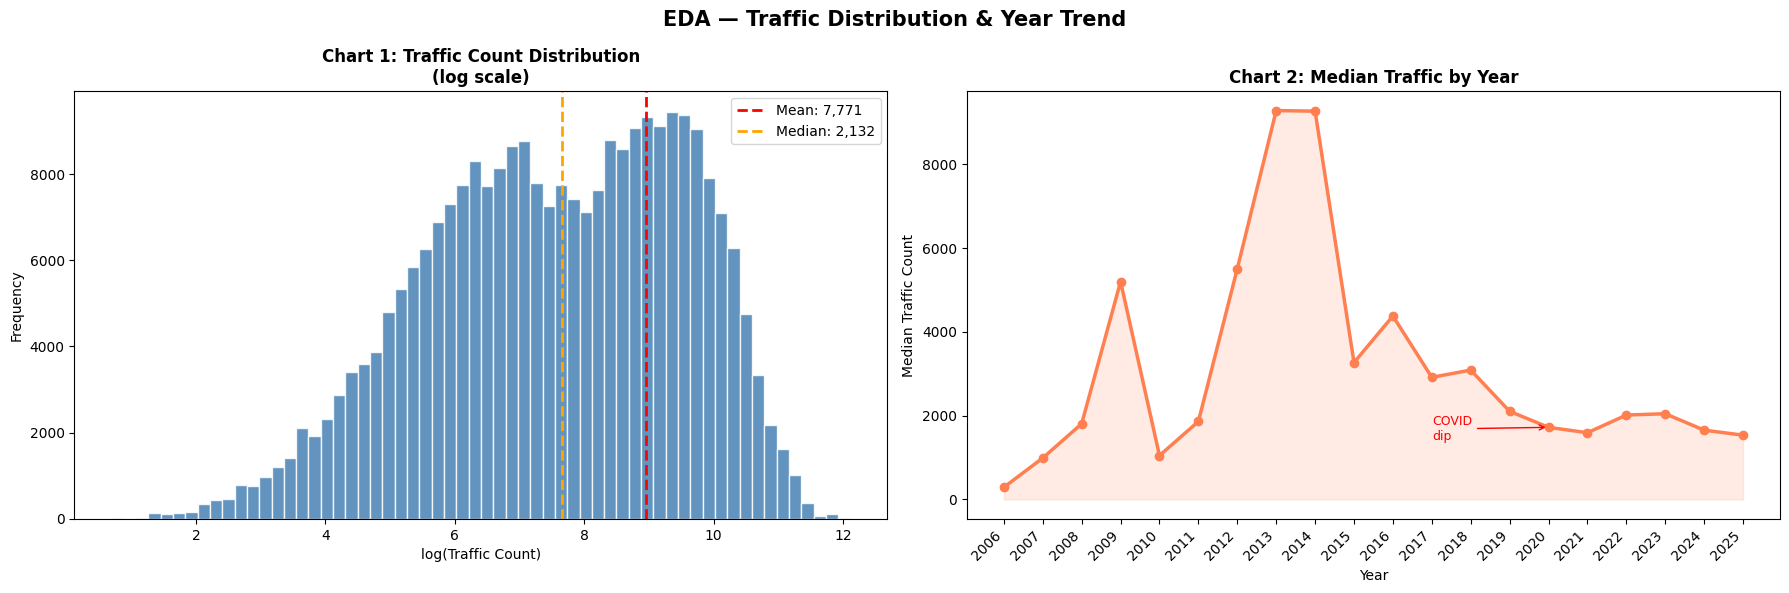

=== TRAFFIC COUNT STATS ===
Min    : 1
Max    : 183,074
Mean   : 7,771
Median : 2,132

💡 Mean >> Median → data is RIGHT SKEWED
💡 Log transform needed before ML!


In [108]:
# ─────────────────────────────────────────
# EDA — CHART 1 & 2
# Distribution & Year Trend
# ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('EDA — Traffic Distribution & Year Trend',
             fontsize=15, fontweight='bold')

# ── Chart 1: Traffic Count Distribution ──
axes[0].hist(np.log1p(df['traffic_count']),
             bins=60, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[0].set_title('Chart 1: Traffic Count Distribution\n(log scale)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('log(Traffic Count)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.log1p(df['traffic_count'].mean()),
                color='red', linestyle='--',
                linewidth=2, label=f'Mean: {df["traffic_count"].mean():,.0f}')
axes[0].axvline(np.log1p(df['traffic_count'].median()),
                color='orange', linestyle='--',
                linewidth=2, label=f'Median: {df["traffic_count"].median():,.0f}')
axes[0].legend()

# ── Chart 2: Traffic by Year ─────────────
year_avg = df.groupby('year')['traffic_count'].median()
axes[1].plot(year_avg.index, year_avg.values,
             color='coral', linewidth=2.5,
             marker='o', markersize=6)
axes[1].fill_between(year_avg.index, year_avg.values,
                      alpha=0.15, color='coral')

# Highlight COVID year
if 2020 in year_avg.index:
    axes[1].annotate('COVID\ndip',
                     xy=(2020, year_avg[2020]),
                     xytext=(2017, year_avg[2020] - 300),
                     arrowprops=dict(arrowstyle='->',
                                     color='red'),
                     fontsize=9, color='red')

axes[1].set_title('Chart 2: Median Traffic by Year',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Median Traffic Count')
axes[1].set_xticks(year_avg.index)
axes[1].set_xticklabels(year_avg.index,
                         rotation=45, ha='right')

plt.tight_layout()
plt.savefig('eda_chart1_2.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print stats
print("=== TRAFFIC COUNT STATS ===")
print(f"Min    : {df['traffic_count'].min():,}")
print(f"Max    : {df['traffic_count'].max():,}")
print(f"Mean   : {df['traffic_count'].mean():,.0f}")
print(f"Median : {df['traffic_count'].median():,.0f}")
print(f"\n💡 Mean >> Median → data is RIGHT SKEWED")
print(f"💡 Log transform needed before ML!")


C:\Users\vilas\AppData\Local\Temp\ipykernel_20188\4076214320.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(class_avg.index,


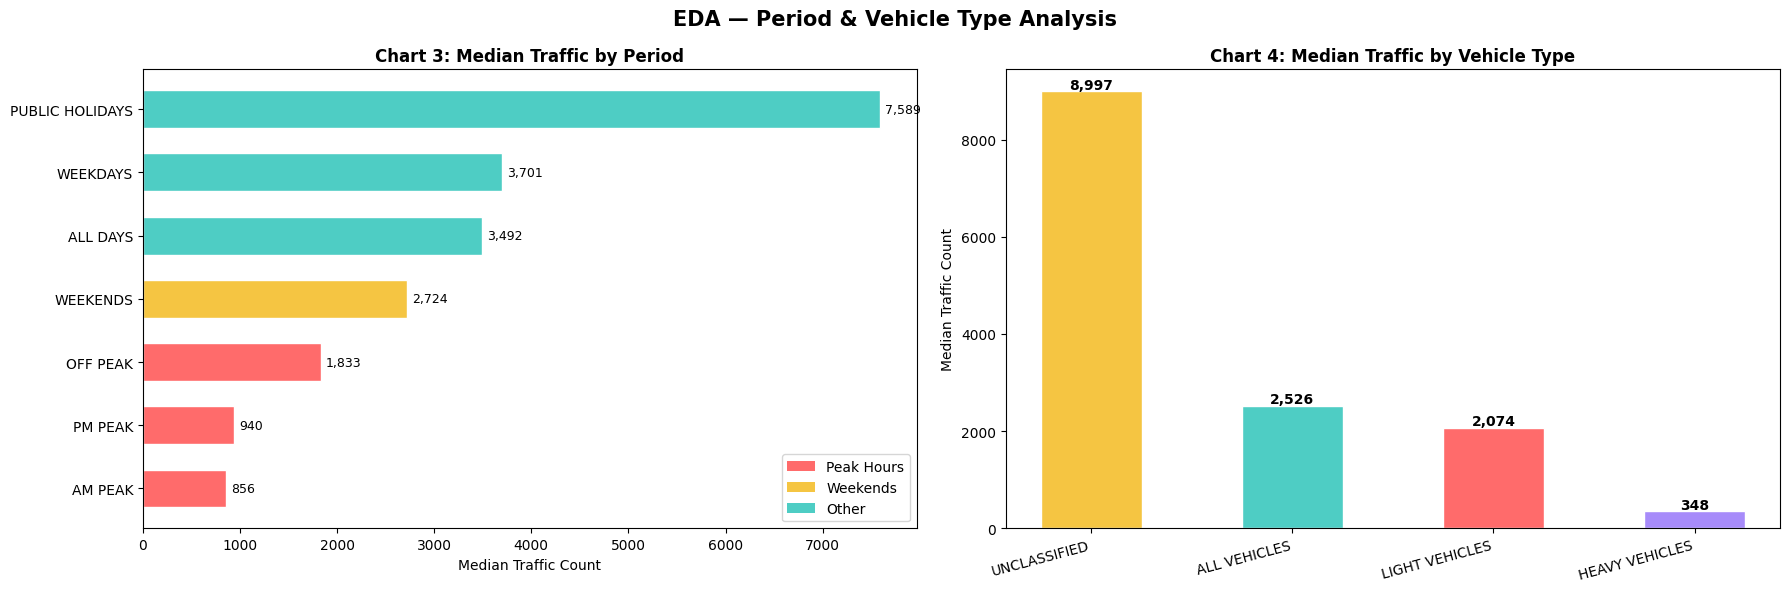

=== KEY INSIGHTS ===

Highest period : PUBLIC HOLIDAYS (7,589)
Lowest period  : AM PEAK (856)

Highest vehicle: UNCLASSIFIED (8,997)
Lowest vehicle : HEAVY VEHICLES (348)


In [109]:
# ─────────────────────────────────────────
# EDA — CHART 3 & 4
# Period & Vehicle Type
# ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('EDA — Period & Vehicle Type Analysis',
             fontsize=15, fontweight='bold')

# ── Chart 3: Traffic by Period ────────────
period_avg = df.groupby('period')['traffic_count']\
               .median().sort_values(ascending=True)

colors = ['#ff6b6b' if 'PEAK' in p 
          else '#f5c542' if 'WEEKEND' in p
          else '#4ecdc4' 
          for p in period_avg.index]

bars = axes[0].barh(period_avg.index,
                     period_avg.values,
                     color=colors,
                     edgecolor='white',
                     height=0.6)
axes[0].set_title('Chart 3: Median Traffic by Period',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Median Traffic Count')

# Value labels
for bar, val in zip(bars, period_avg.values):
    axes[0].text(val + 50,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:,.0f}',
                 va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#ff6b6b', label='Peak Hours'),
    Patch(facecolor='#f5c542', label='Weekends'),
    Patch(facecolor='#4ecdc4', label='Other'),
]
axes[0].legend(handles=legend_elements,
               loc='lower right')

# ── Chart 4: Traffic by Vehicle Type ──────
class_avg = df.groupby('classification_type')['traffic_count']\
              .median().sort_values(ascending=False)

bar_colors = ['#f5c542', '#4ecdc4', 
              '#ff6b6b', '#a78bfa']
bars2 = axes[1].bar(class_avg.index,
                     class_avg.values,
                     color=bar_colors,
                     edgecolor='white',
                     width=0.5)
axes[1].set_title('Chart 4: Median Traffic by Vehicle Type',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Median Traffic Count')
axes[1].set_xticklabels(class_avg.index,
                         rotation=15, ha='right')

# Value labels
for bar, val in zip(bars2, class_avg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{val:,.0f}',
                 ha='center', fontsize=10,
                 fontweight='bold')

plt.tight_layout()
plt.savefig('eda_chart3_4.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Insights
print("=== KEY INSIGHTS ===")
print(f"\nHighest period : {period_avg.idxmax()} "
      f"({period_avg.max():,.0f})")
print(f"Lowest period  : {period_avg.idxmin()} "
      f"({period_avg.min():,.0f})")
print(f"\nHighest vehicle: {class_avg.idxmax()} "
      f"({class_avg.max():,.0f})")
print(f"Lowest vehicle : {class_avg.idxmin()} "
      f"({class_avg.min():,.0f})")

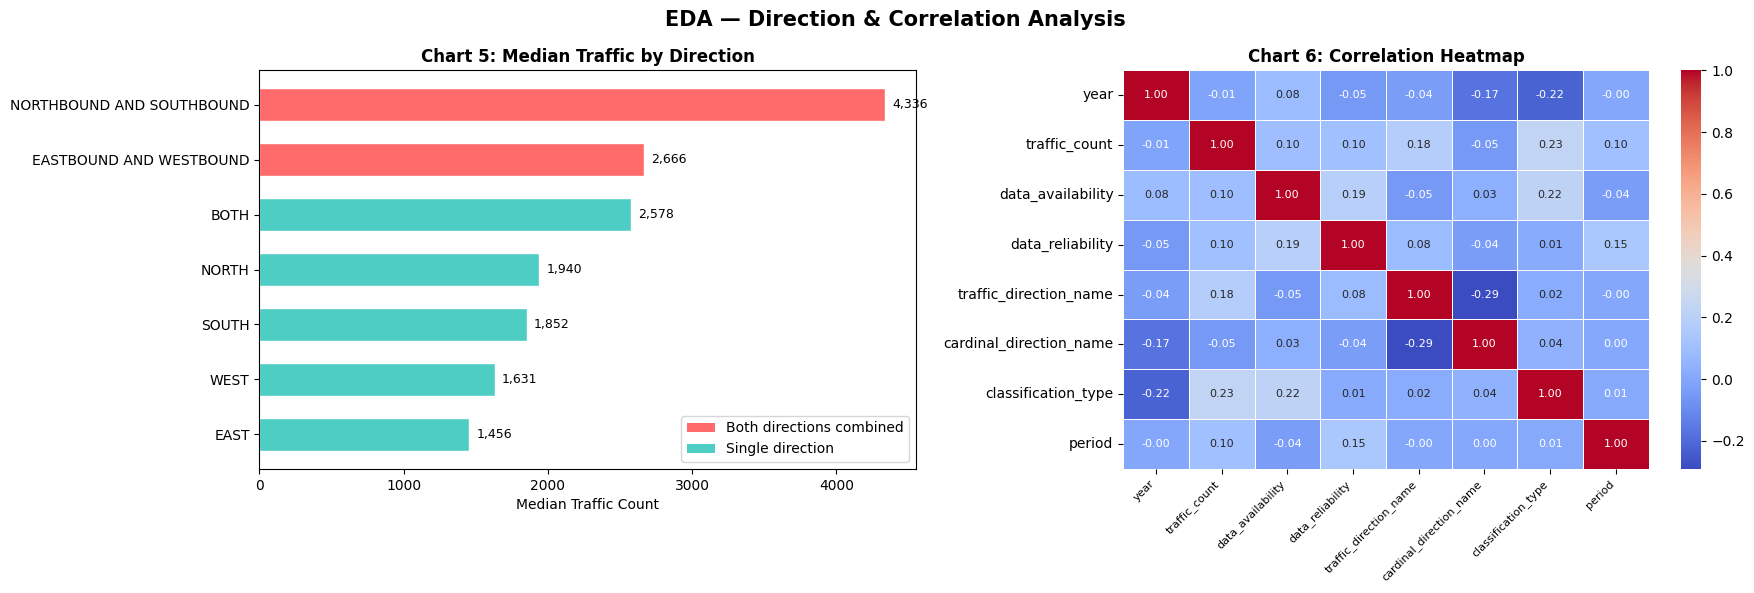

=== CORRELATION WITH TRAFFIC COUNT ===
  classification_type             0.233  🟢 Weak
  traffic_direction_name          0.179  🟢 Weak
  period                          0.104  🟢 Weak
  data_reliability                0.103  🟢 Weak
  data_availability               0.097  🟢 Weak
  year                           -0.012  🟢 Weak
  cardinal_direction_name        -0.051  🟢 Weak


In [110]:
# ─────────────────────────────────────────
# EDA — CHART 5 & 6
# Direction & Correlation Heatmap
# ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('EDA — Direction & Correlation Analysis',
             fontsize=15, fontweight='bold')

# ── Chart 5: Traffic by Direction ─────────
dir_avg = df.groupby('cardinal_direction_name')['traffic_count']\
            .median().sort_values(ascending=True)

bar_colors = ['#4ecdc4' if 'AND' not in d
              else '#ff6b6b'
              for d in dir_avg.index]

bars = axes[0].barh(dir_avg.index,
                     dir_avg.values,
                     color=bar_colors,
                     edgecolor='white',
                     height=0.6)
axes[0].set_title('Chart 5: Median Traffic by Direction',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Median Traffic Count')

for bar, val in zip(bars, dir_avg.values):
    axes[0].text(val + 50,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:,.0f}',
                 va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#ff6b6b',
          label='Both directions combined'),
    Patch(facecolor='#4ecdc4',
          label='Single direction'),
]
axes[0].legend(handles=legend_elements)

# ── Chart 6: Correlation Heatmap ──────────
# Create temp encoded cols just for heatmap
temp = df.copy()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in ['traffic_direction_name',
            'cardinal_direction_name',
            'classification_type',
            'period']:
    temp[col] = le.fit_transform(temp[col])

num_cols = ['year', 'traffic_count',
            'data_availability',
            'data_reliability',
            'traffic_direction_name',
            'cardinal_direction_name',
            'classification_type',
            'period']

corr = temp[num_cols].corr()
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            ax=axes[1],
            linewidths=0.5,
            annot_kws={'size': 8})
axes[1].set_title('Chart 6: Correlation Heatmap',
                   fontsize=12, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(),
                         rotation=45, ha='right',
                         fontsize=8)

plt.tight_layout()
plt.savefig('eda_chart5_6.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Insights
print("=== CORRELATION WITH TRAFFIC COUNT ===")
traffic_corr = corr['traffic_count'].sort_values(
                ascending=False)
for col, val in traffic_corr.items():
    if col != 'traffic_count':
        strength = "🔴 Strong" if abs(val) > 0.5 \
                   else "🟡 Medium" if abs(val) > 0.3 \
                   else "🟢 Weak"
        print(f"  {col:<30} {val:>6.3f}  {strength}")

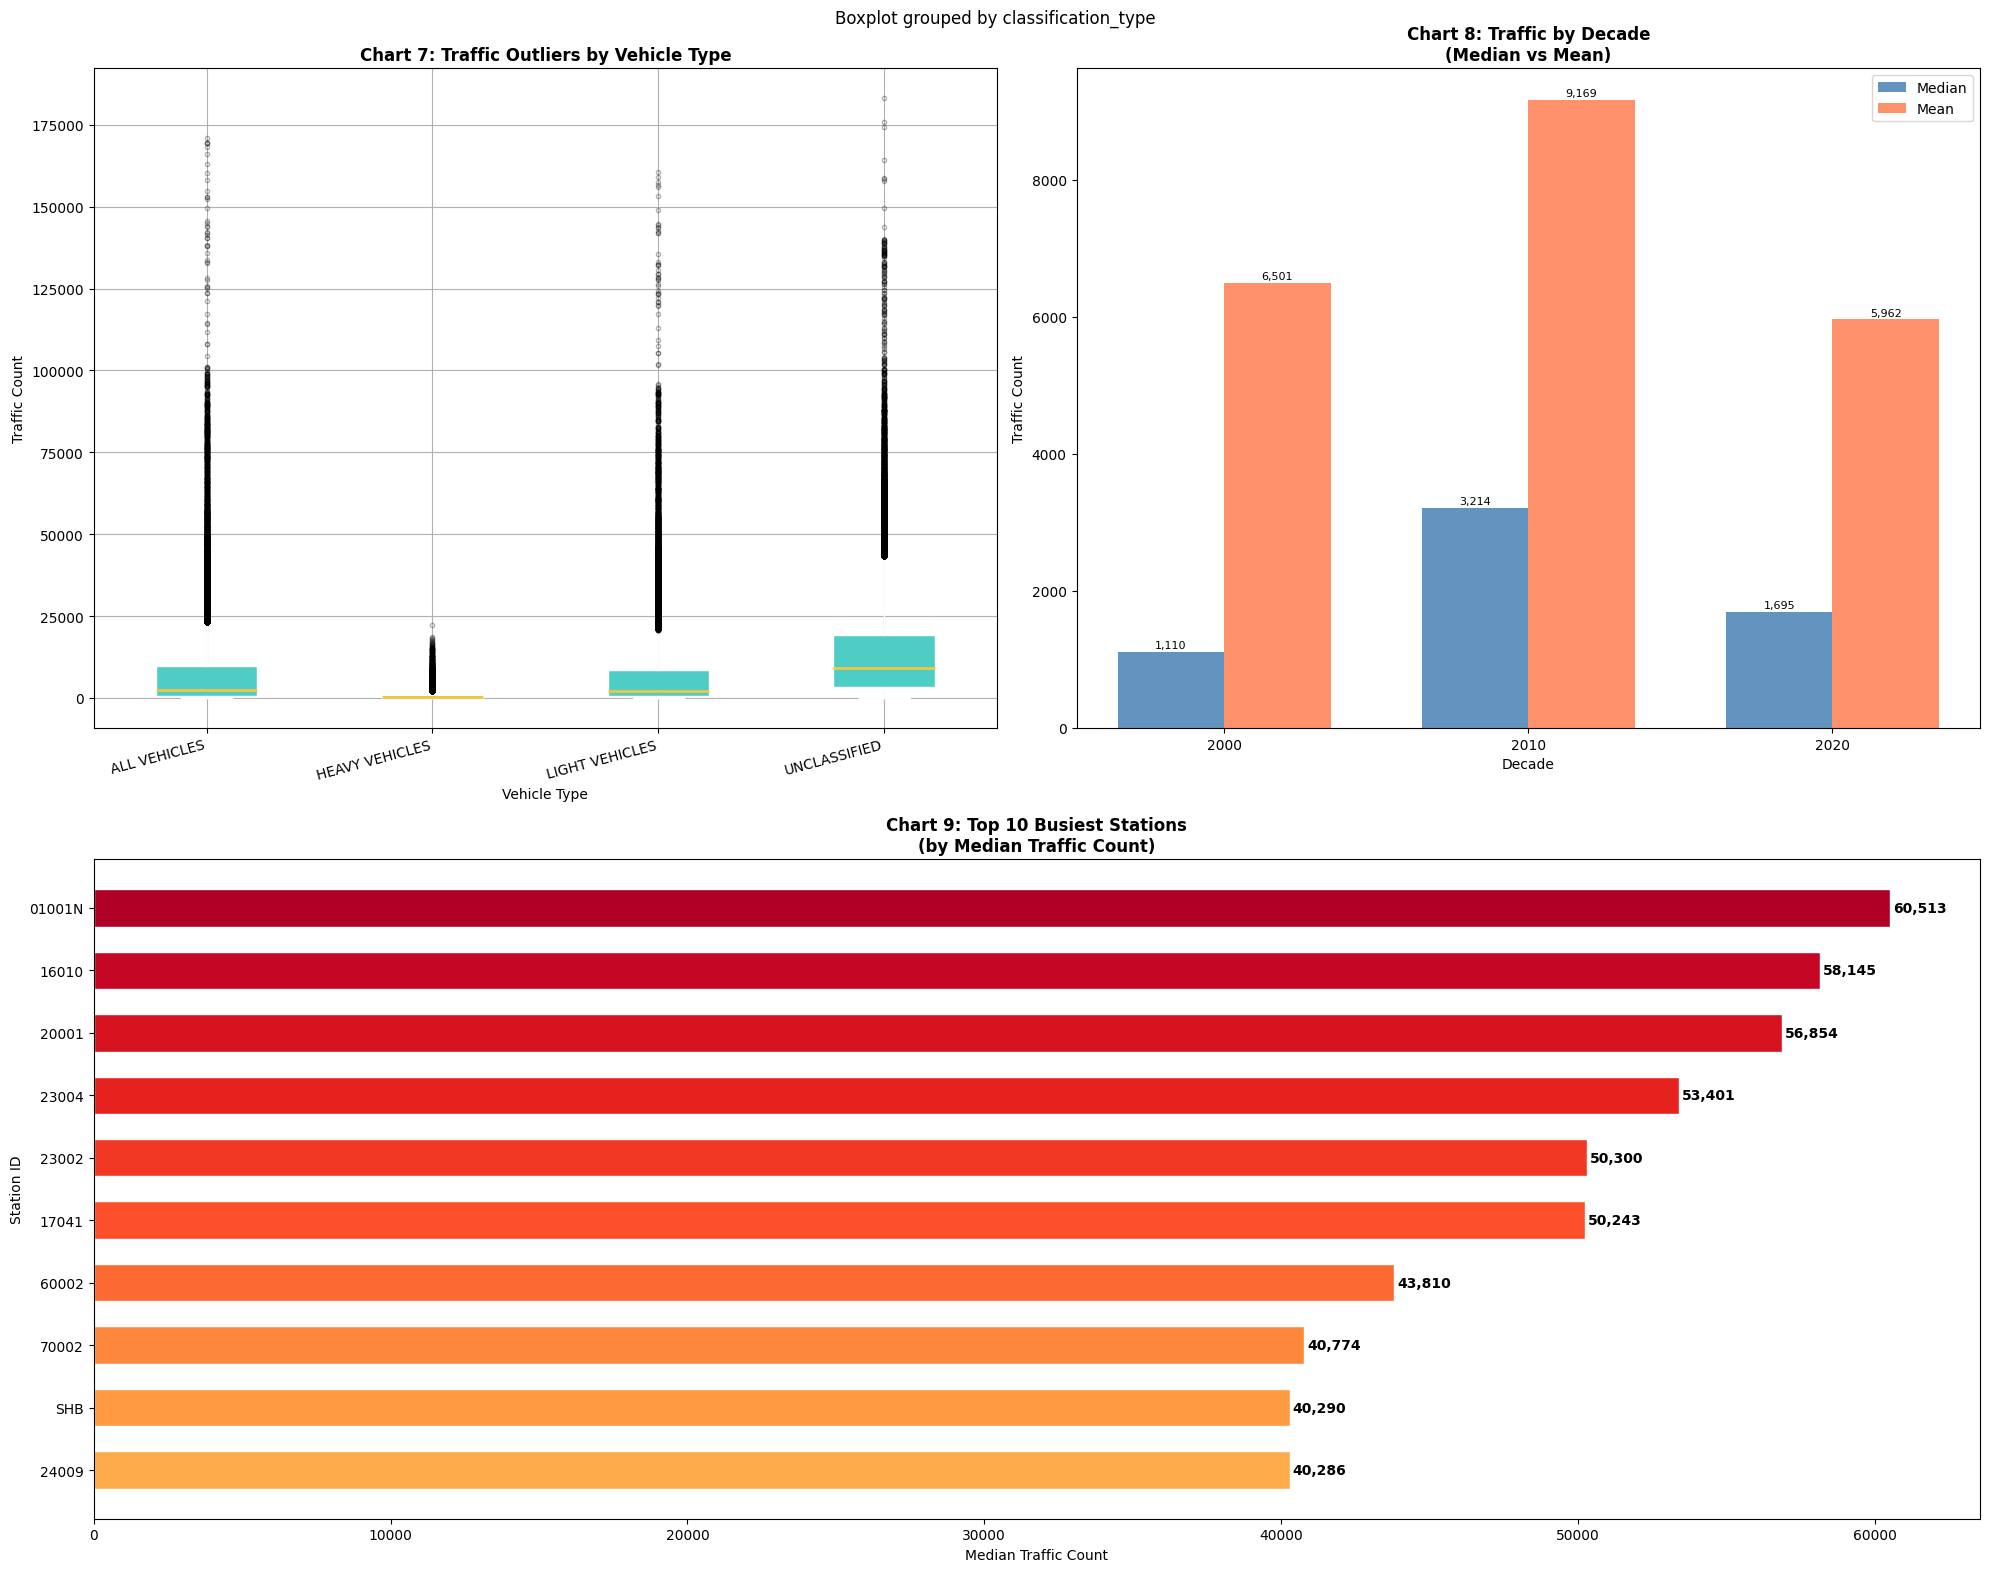

✅ Charts 7, 8, 9 saved!

=== TOP 10 BUSIEST STATIONS ===
  01001N              60,513 vehicles
  16010               58,145 vehicles
  20001               56,854 vehicles
  23004               53,401 vehicles
  23002               50,300 vehicles
  17041               50,243 vehicles
  60002               43,810 vehicles
  70002               40,774 vehicles
  SHB                 40,290 vehicles
  24009               40,286 vehicles


In [111]:
# ─────────────────────────────────────────
# EDA — CHART 7, 8 & 9
# Boxplot, Decade & Top Stations
# ─────────────────────────────────────────

fig = plt.figure(figsize=(20, 16))
fig.suptitle('EDA — Outliers, Decade & Top Stations',
             fontsize=15, fontweight='bold')

# ── Chart 7: Boxplot by Vehicle Type ──────
ax7 = fig.add_subplot(2, 2, 1)
df.boxplot(column='traffic_count',
           by='classification_type',
           ax=ax7,
           patch_artist=True,
           boxprops=dict(facecolor='#4ecdc4',
                         color='white'),
           medianprops=dict(color='#f5c542',
                            linewidth=2),
           whiskerprops=dict(color='white'),
           capprops=dict(color='white'),
           flierprops=dict(marker='o',
                           color='#ff6b6b',
                           alpha=0.3,
                           markersize=3))
ax7.set_title('Chart 7: Traffic Outliers\nby Vehicle Type',
               fontsize=12, fontweight='bold')
ax7.set_xlabel('Vehicle Type')
ax7.set_ylabel('Traffic Count')
ax7.set_xticklabels(ax7.get_xticklabels(),
                     rotation=15, ha='right')
plt.sca(ax7)
plt.title('Chart 7: Traffic Outliers by Vehicle Type',
           fontsize=12, fontweight='bold')

# ── Chart 8: Traffic by Decade ────────────
ax8 = fig.add_subplot(2, 2, 2)
df['decade'] = (df['year'] // 10) * 10
decade_avg = df.groupby('decade')['traffic_count']\
               .agg(['median', 'mean'])
x     = np.arange(len(decade_avg))
width = 0.35

bars1 = ax8.bar(x - width/2,
                 decade_avg['median'],
                 width,
                 label='Median',
                 color='steelblue',
                 alpha=0.85)
bars2 = ax8.bar(x + width/2,
                 decade_avg['mean'],
                 width,
                 label='Mean',
                 color='coral',
                 alpha=0.85)

ax8.set_title('Chart 8: Traffic by Decade\n(Median vs Mean)',
               fontsize=12, fontweight='bold')
ax8.set_xlabel('Decade')
ax8.set_ylabel('Traffic Count')
ax8.set_xticks(x)
ax8.set_xticklabels(decade_avg.index.astype(str))
ax8.legend()

for bar, val in zip(bars1, decade_avg['median']):
    ax8.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f'{val:,.0f}',
             ha='center', fontsize=8)
for bar, val in zip(bars2, decade_avg['mean']):
    ax8.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f'{val:,.0f}',
             ha='center', fontsize=8)

# ── Chart 9: Top 10 Busiest Stations ──────
ax9 = fig.add_subplot(2, 1, 2)
top10 = df.groupby('station_id')['traffic_count']\
          .median().nlargest(10).sort_values(ascending=True)

colors_top = plt.cm.YlOrRd(
    np.linspace(0.4, 0.9, 10))
bars = ax9.barh(top10.index.astype(str),
                 top10.values,
                 color=colors_top,
                 edgecolor='white',
                 height=0.6)
ax9.set_title('Chart 9: Top 10 Busiest Stations\n'
               '(by Median Traffic Count)',
               fontsize=12, fontweight='bold')
ax9.set_xlabel('Median Traffic Count')
ax9.set_ylabel('Station ID')

for bar, val in zip(bars, top10.values):
    ax9.text(val + 100,
             bar.get_y() + bar.get_height()/2,
             f'{val:,.0f}',
             va='center', fontsize=10,
             fontweight='bold')

plt.tight_layout()
plt.savefig('eda_chart7_8_9.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Drop decade — we recreate in feature engineering
df.drop(columns=['decade'], inplace=True)

print("✅ Charts 7, 8, 9 saved!")
print("\n=== TOP 10 BUSIEST STATIONS ===")
for station, traffic in top10.sort_values(
                          ascending=False).items():
    print(f"  {station:<15} {traffic:>10,.0f} vehicles")

In [112]:
df.head(5)

,station_id,traffic_direction_name,cardinal_direction_name,classification_type,year,period,traffic_count,data_availability,data_reliability
0,02015,PRESCRIBED AND COUNTER,BOTH,UNCLASSIFIED,2018,WEEKDAYS,39273,37.0,93.0
1,6157,COUNTER,SOUTH,HEAVY VEHICLES,2022,ALL DAYS,705,1.0,92.0
2,83011,COUNTER,SOUTH,HEAVY VEHICLES,2020,ALL DAYS,1722,10.0,77.0
3,F3FWY006,PRESCRIBED AND COUNTER,BOTH,HEAVY VEHICLES,2018,PM PEAK,2178,37.0,93.0
4,34029,COUNTER,SOUTH,UNCLASSIFIED,2016,WEEKDAYS,7541,37.0,93.0


In [113]:
df.columns.tolist()

['station_id',
 'traffic_direction_name',
 'cardinal_direction_name',
 'classification_type',
 'year',
 'period',
 'traffic_count',
 'data_availability',
 'data_reliability']

In [114]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
encode_cols=[
    'station_id',
    'traffic_direction_name',
    'cardinal_direction_name',
    'classification_type',
    'period']
for i in encode_cols:
    df[i +'_enc']=le.fit_transform(df[i].astype(str))

In [115]:
df.columns.to_list()

['station_id',
 'traffic_direction_name',
 'cardinal_direction_name',
 'classification_type',
 'year',
 'period',
 'traffic_count',
 'data_availability',
 'data_reliability',
 'station_id_enc',
 'traffic_direction_name_enc',
 'cardinal_direction_name_enc',
 'classification_type_enc',
 'period_enc']

In [118]:
# ─────────────────────────────────────────
# FEATURE ENGINEERING
# Create new smart features from existing
# ─────────────────────────────────────────

# Feature 1: is_peak
# Peak hours always have different traffic
df['is_peak'] = df['period'].str.contains(
                'PEAK').astype(int)

# Feature 2: is_weekend
# Weekend traffic very different to weekdays
df['is_weekend'] = df['period'].str.contains(
                   'WEEKEND').astype(int)

# Feature 3: is_holiday
# Holidays cause unusual traffic patterns
df['is_holiday'] = df['period'].str.contains(
                   'HOLIDAY').astype(int)

# Feature 4: is_both_directions
# Both directions = double the count naturally
df['is_both_directions'] = df[
    'traffic_direction_name'].str.contains(
    'AND').astype(int)

# Feature 5: is_heavy
# Heavy vehicles have very different patterns
df['is_heavy'] = (
    df['classification_type'] == 'HEAVY VEHICLES'
).astype(int)

# Feature 6: decade
# Captures long term traffic growth trends
df['decade'] = (df['year'] // 10) * 10

# ── Verify ────────────────────────────────
new_features = ['is_peak', 'is_weekend',
                'is_holiday', 'is_both_directions',
                'is_heavy', 'decade']

print("=== NEW FEATURES CREATED ===\n")
for f in new_features:
    print(f"--- {f} ---")
    print(df[f].value_counts())
    print()

print(f"✅ Total columns now: {df.shape[1]}")
print(f"\nSample:")
df[['period', 'is_peak', 'is_weekend',
    'is_holiday', 'classification_type',
    'is_heavy', 'year', 'decade']].head(5)

=== NEW FEATURES CREATED ===

--- is_peak ---
is_peak
0    142858
1    122433
Name: count, dtype: int64

--- is_weekend ---
is_weekend
0    224684
1     40607
Name: count, dtype: int64

--- is_holiday ---
is_holiday
0    244700
1     20591
Name: count, dtype: int64

--- is_both_directions ---
is_both_directions
0    186921
1     78370
Name: count, dtype: int64

--- is_heavy ---
is_heavy
0    202126
1     63165
Name: count, dtype: int64

--- decade ---
decade
2010    139539
2020     65775
2000     59977
Name: count, dtype: int64

✅ Total columns now: 20

Sample:


,period,is_peak,is_weekend,is_holiday,classification_type,is_heavy,year,decade
0,WEEKDAYS,0,0,0,UNCLASSIFIED,0,2018,2010
1,ALL DAYS,0,0,0,HEAVY VEHICLES,1,2022,2020
2,ALL DAYS,0,0,0,HEAVY VEHICLES,1,2020,2020
3,PM PEAK,1,0,0,HEAVY VEHICLES,1,2018,2010
4,WEEKDAYS,0,0,0,UNCLASSIFIED,0,2016,2010


In [ ]:
FEATURES = [
    # Encoded categorical
    'station_id_enc',
    'traffic_direction_name_enc',
    'cardinal_direction_name_enc',
    'classification_type_enc',
    'period_enc',

    # Numeric
    'year',
    'data_availability',
    'data_reliability',

    # Engineered
    'is_peak',
    'is_weekend',
    'is_holiday',
    'is_both_directions',
    'is_heavy',
    'decade'
]
x=df[FEATURES]
y=np.log1p(df['traffic_count'])
print(f"X shape   : {x.shape}")
print(f"y shape   : {y.shape}")
print(f"Features  : {len(FEATURES)}")

X shape   : (265291, 14)
y shape   : (265291,)
Features  : 14
Target    : 0         10.578318
1          6.559615
2          7.451822
3          7.686621
4          8.928243
            ...    
273908     7.563720
273909     5.468060
273910     5.786897
273911     5.262690
273912     5.820083
Name: traffic_count, Length: 265291, dtype: float64 (log transformed)


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


✅ Split complete!

                Shape       Rows      %
----------------------------------------
X_train     (212232, 14)    212,232  (80%)
X_test       (53059, 14)     53,059  (20%)
y_train        (212232,)    212,232  (80%)
y_test          (53059,)     53,059  (20%)

💡 Training on : 212,232 rows
💡 Testing on  : 53,059 rows
💡 Features    : 14


In [133]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (RandomForestRegressor,
                               GradientBoostingRegressor,
                               ExtraTreesRegressor)
from sklearn.metrics import (mean_absolute_error,
                              mean_squared_error,
                              r2_score)
from xgboost import XGBRegressor

In [135]:
pipelines = {
    # Needs scaling
    'Linear Regression' : Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LinearRegression())
    ]),
    'Ridge Regression'  : Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=1.0))
    ]),
    'Lasso Regression'  : Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Lasso(alpha=1.0))
    ]),
    'KNN'               : Pipeline([
        ('scaler', StandardScaler()),
        ('model',  KNeighborsRegressor(
                    n_neighbors=5, n_jobs=-1))
    ]),
    # No scaling needed
    'Decision Tree'     : Pipeline([
        ('model', DecisionTreeRegressor(
                   random_state=42))
    ]),
    'Random Forest'     : Pipeline([
        ('model', RandomForestRegressor(
                   n_estimators=100,
                   random_state=42,
                   n_jobs=-1))
    ]),
    'Extra Trees'       : Pipeline([
        ('model', ExtraTreesRegressor(
                   n_estimators=100,
                   random_state=42,
                   n_jobs=-1))
    ]),
    'Gradient Boosting' : Pipeline([
        ('model', GradientBoostingRegressor(
                   n_estimators=100,
                   random_state=42))
    ]),
    'XGBoost'           : Pipeline([
        ('model', XGBRegressor(
                   n_estimators=100,
                   random_state=42,
                   verbosity=0))
    ]),
}
results = {}

print("Training pipelines...\n")
print(f"{'Model':<25} {'R²':>8} {'MAE':>12} {'RMSE':>12}")
print("-" * 60)
for name,pipeline in pipelines.items():
    pipeline.fit(x_train,y_train)
    y_pred=pipeline.predict(x_test)
    y_pred_orig = np.expm1(y_pred)
    y_test_orig = np.expm1(y_test)
    r2=r2_score(y_pred_orig,y_test_orig)
    mae=mean_absolute_error(y_pred_orig,y_test_orig)
    rmse=np.sqrt(mean_squared_error(y_pred_orig,y_test_orig))
    results[name]={'PIPELINE':pipeline,'R2':r2,'MAE':mae,'RMSE':rmse,'PRED':y_pred_orig}
    print(f"{name:<25} {r2:>8.4f} {mae:>12,.0f} {rmse:>12,.0f}")

Training pipelines...

Model                           R²          MAE         RMSE
------------------------------------------------------------
Linear Regression          -4.7660        5,832       11,780
Ridge Regression           -4.7661        5,832       11,780
Lasso Regression          -506272.4234        7,097       14,000
KNN                         0.2913        3,772        8,252
Decision Tree               0.9790          566        1,850
Random Forest               0.9853          537        1,527
Extra Trees                 0.9256        1,137        3,222
Gradient Boosting          -0.0971        3,682        8,301
XGBoost                     0.7749        2,256        5,312


In [142]:
best = max(results,key=lambda x: results[x]['R2'])
print('',best)
print(f" R² : {round(results[best]['R2'],3)}")
print(f" MAE : {round(results[best]['MAE'],3)}")
print(f" RMSE : {round(results[best]['RMSE'],3)}")

 Random Forest
 R² : 0.985
 MAE : 537.226
 RMSE : 1527.232


C:\Users\vilas\AppData\Local\Temp\ipykernel_20188\759985194.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(model_names,
C:\Users\vilas\AppData\Local\Temp\ipykernel_20188\759985194.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(model_names,


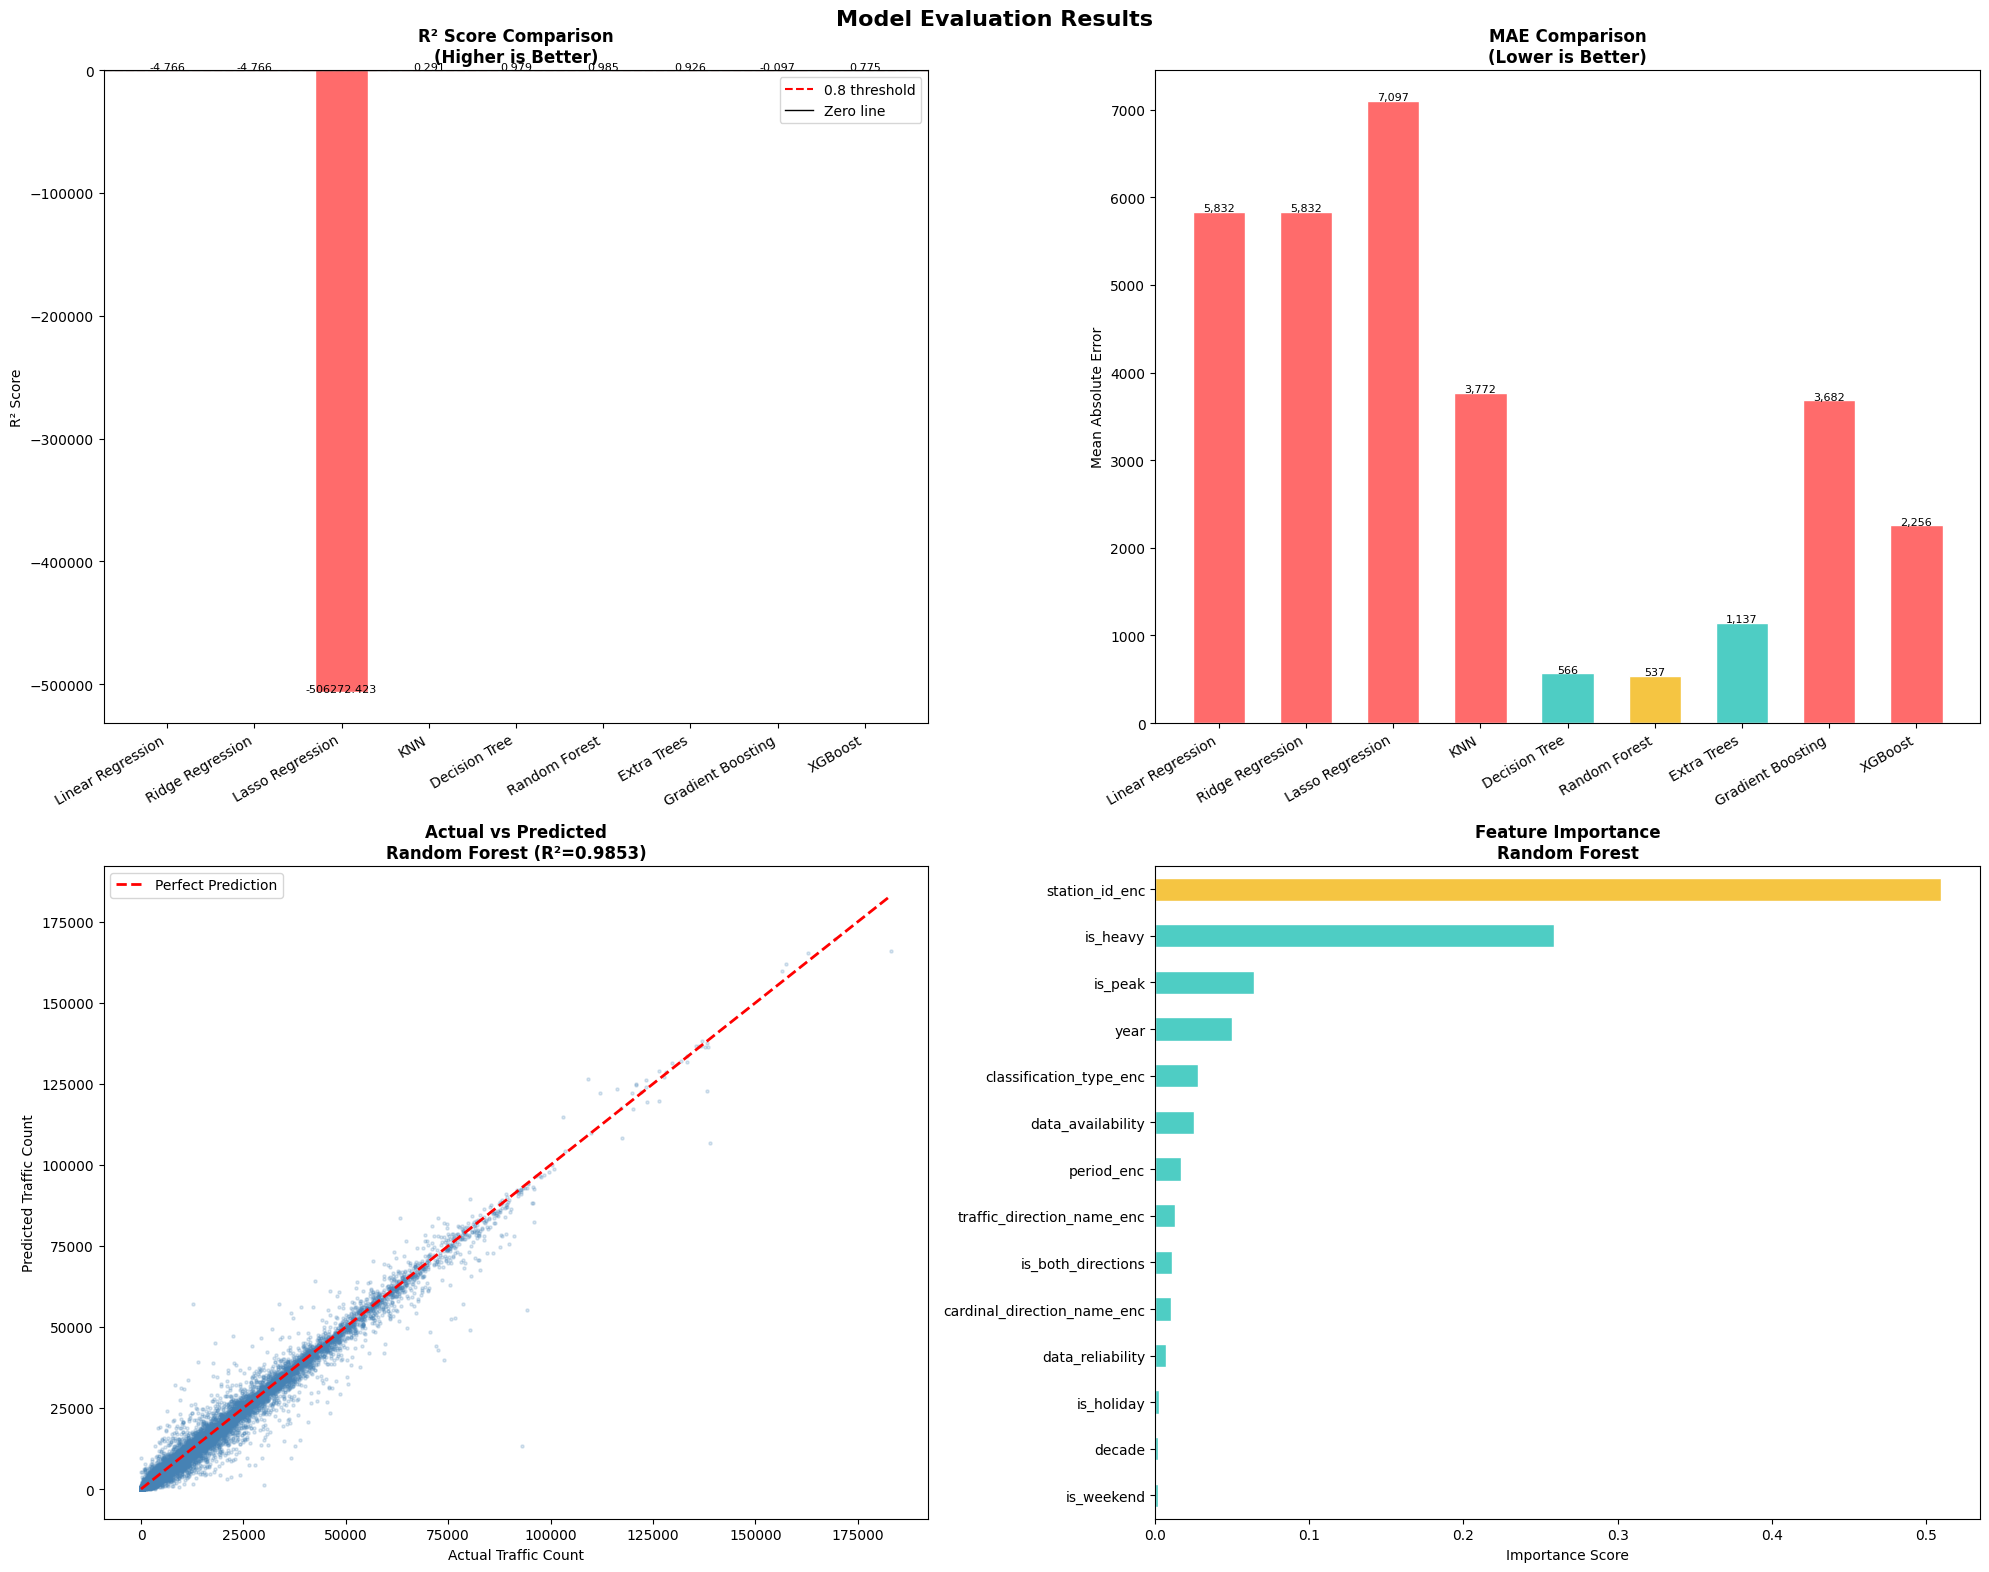

✅ Model results saved!

=== LEADERBOARD ===

Rank   Model                           R²        MAE       RMSE
--------------------------------------------------------------
1      Random Forest               0.9853        537      1,527 🏆
2      Decision Tree               0.9790        566      1,850
3      Extra Trees                 0.9256      1,137      3,222
4      XGBoost                     0.7749      2,256      5,312
5      KNN                         0.2913      3,772      8,252
6      Gradient Boosting          -0.0971      3,682      8,301
7      Linear Regression          -4.7660      5,832     11,780
8      Ridge Regression           -4.7661      5,832     11,780
9      Lasso Regression          -506272.4234      7,097     14,000


In [145]:
# ─────────────────────────────────────────
# EVALUATE & VISUALIZE RESULTS
# ─────────────────────────────────────────

fig = plt.figure(figsize=(20, 16))
fig.suptitle('Model Evaluation Results',
             fontsize=16, fontweight='bold')

# ── Chart 1: R² Comparison ────────────────
ax1 = fig.add_subplot(2, 2, 1)
model_names = list(results.keys())
r2_values   = [results[m]['R2'] for m in model_names]
bar_colors  = ['#f5c542' if m == best
               else '#4ecdc4' if results[m]['R2'] > 0.8
               else '#ff6b6b'
               for m in model_names]

bars = ax1.bar(model_names, r2_values,
               color=bar_colors,
               edgecolor='white',
               width=0.6)
ax1.set_title('R² Score Comparison\n(Higher is Better)',
               fontsize=12, fontweight='bold')
ax1.set_ylabel('R² Score')
ax1.set_xticklabels(model_names,
                     rotation=30, ha='right')
ax1.axhline(y=0.8, color='red',
            linestyle='--', linewidth=1.5,
            label='0.8 threshold')
ax1.axhline(y=0, color='black',
            linestyle='-', linewidth=1,
            label='Zero line')
ax1.legend()

for bar, val in zip(bars, r2_values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02
             if val >= 0 else bar.get_height() - 0.3,
             f'{val:.3f}',
             ha='center', fontsize=8)

# ── Chart 2: MAE Comparison ───────────────
ax2 = fig.add_subplot(2, 2, 2)
mae_values = [results[m]['MAE'] for m in model_names]
bars2 = ax2.bar(model_names, mae_values,
                color=bar_colors,
                edgecolor='white',
                width=0.6)
ax2.set_title('MAE Comparison\n(Lower is Better)',
               fontsize=12, fontweight='bold')
ax2.set_ylabel('Mean Absolute Error')
ax2.set_xticklabels(model_names,
                     rotation=30, ha='right')
for bar, val in zip(bars2, mae_values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 10,
             f'{val:,.0f}',
             ha='center', fontsize=8)

# ── Chart 3: Actual vs Predicted ──────────
ax3 = fig.add_subplot(2, 2, 3)
y_test_orig = np.expm1(y_test)
best_pred   = results[best]['PRED']

ax3.scatter(y_test_orig, best_pred,
            alpha=0.2, s=5,
            color='steelblue')
lim = max(y_test_orig.max(),
          best_pred.max())
ax3.plot([0, lim], [0, lim],
         'r--', linewidth=2,
         label='Perfect Prediction')
ax3.set_title(f'Actual vs Predicted\n'
               f'{best} (R²='
               f'{results[best]["R2"]:.4f})',
               fontsize=12, fontweight='bold')
ax3.set_xlabel('Actual Traffic Count')
ax3.set_ylabel('Predicted Traffic Count')
ax3.legend()

# ── Chart 4: Feature Importance ───────────
ax4 = fig.add_subplot(2, 2, 4)
best_model  = results[best]['PIPELINE']\
              .named_steps['model']

importances = pd.Series(
    best_model.feature_importances_,
    index=FEATURES
).sort_values()

colors_fi = ['#f5c542' if v == importances.max()
             else '#4ecdc4'
             for v in importances.values]

importances.plot(kind='barh',
                 ax=ax4,
                 color=colors_fi,
                 edgecolor='white')
ax4.set_title(f'Feature Importance\n{best}',
               fontsize=12, fontweight='bold')
ax4.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('model_results.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Model results saved!")
print(f"\n=== LEADERBOARD ===")
print(f"\n{'Rank':<6} {'Model':<25} {'R²':>8} "
      f"{'MAE':>10} {'RMSE':>10}")
print("-" * 62)
for rank, name in enumerate(
    sorted(results,
           key=lambda x: -results[x]['R2']), 1):
    star = ' 🏆' if name == best else ''
    print(f"{rank:<6} {name:<25} "
          f"{results[name]['R2']:>8.4f} "
          f"{results[name]['MAE']:>10,.0f} "
          f"{results[name]['RMSE']:>10,.0f}{star}")

In [ ]:
# ─────────────────────────────────────────
# PREDICT TRAFFIC FOR ANY ROAD
# ─────────────────────────────────────────

def predict_traffic(
    station_id_enc,
    year,
    period,
    classification_type,
    cardinal_direction,
    traffic_direction,
    data_availability = 93,
    data_reliability  = 93
):
    # ── Mappings from actual encodings ────
    period_map = {
        'ALL DAYS'       : 0,
        'AM PEAK'        : 1,
        'OFF PEAK'       : 2,
        'PM PEAK'        : 3,
        'PUBLIC HOLIDAYS': 4,
        'WEEKDAYS'       : 5,
        'WEEKENDS'       : 6
    }
    class_map = {
        'ALL VEHICLES'  : 0,
        'HEAVY VEHICLES': 1,
        'LIGHT VEHICLES': 2,
        'UNCLASSIFIED'  : 3
    }
    direction_map = {
        'BOTH'                     : 0,
        'EAST'                     : 1,
        'EASTBOUND AND WESTBOUND'  : 2,
        'NORTH'                    : 3,
        'NORTHBOUND AND SOUTHBOUND': 4,
        'SOUTH'                    : 5,
        'WEST'                     : 6
    }
    traffic_dir_map = {
        'COUNTER'               : 0,
        'PRESCRIBED'            : 1,
        'PRESCRIBED AND COUNTER': 2
    }

    # ── Engineered features ───────────────
    is_peak            = 1 if 'PEAK'    in period.upper() else 0
    is_weekend         = 1 if 'WEEKEND' in period.upper() else 0
    is_holiday         = 1 if 'HOLIDAY' in period.upper() else 0
    is_both_directions = 1 if 'AND' in traffic_direction.upper() else 0
    is_heavy           = 1 if classification_type.upper() == 'HEAVY VEHICLES' else 0
    decade             = (year // 10) * 10

    # ── Build input ───────────────────────
    input_data = pd.DataFrame([{
        'station_id_enc'               : station_id_enc,
        'traffic_direction_name_enc'   : traffic_dir_map.get(
                                         traffic_direction.upper(), 1),
        'cardinal_direction_name_enc'  : direction_map.get(
                                         cardinal_direction.upper(), 3),
        'classification_type_enc'      : class_map.get(
                                         classification_type.upper(), 0),
        'period_enc'                   : period_map.get(
                                         period.upper(), 5),
        'year'                         : year,
        'data_availability'            : data_availability,
        'data_reliability'             : data_reliability,
        'is_peak'                      : is_peak,
        'is_weekend'                   : is_weekend,
        'is_holiday'                   : is_holiday,
        'is_both_directions'           : is_both_directions,
        'is_heavy'                     : is_heavy,
        'decade'                       : decade
    }])

    input_data = input_data[FEATURES]
    pred_log   = results[best]['PIPELINE'].predict(
                  input_data)[0]
    return int(np.expm1(pred_log))

print("✅ predict_traffic function ready!")

# ── Test with real station data ───────────
print("\n" + "=" * 60)
print("   PREDICTIONS vs ACTUAL — STATION 01001N")
print("=" * 60)

# Real 2024 values we know are correct
real_2024 = {
    'AM PEAK' : 24613,
    'PM PEAK' : 24681,
    'OFF PEAK': 48402,
    'WEEKDAYS': 97696,
    'WEEKENDS': 80401,
    'ALL DAYS': 94212,
}

print(f"\n{'Period':<20} {'Predicted':>12} "
      f"{'Actual':>12} {'Error %':>10} {'':>4}")
print("-" * 62)

for period, actual in real_2024.items():
    pred  = predict_traffic(
        station_id_enc      = 1,
        year                = 2024,
        period              = period,
        classification_type = 'UNCLASSIFIED',
        cardinal_direction  = 'NORTH',
        traffic_direction   = 'PRESCRIBED'
    )
    error    = abs(pred - actual) / actual * 100
    status   = "✅" if error < 10 else \
               "⚠️" if error < 20 else "❌"
    print(f"{period:<20} {pred:>12,} "
          f"{actual:>12,} {error:>9.1f}% {status}")

# ── Year trend ────────────────────────────
print(f"\n{'='*60}")
print(f"📅 YEAR TREND — Station 01001N (ALL DAYS)")
print(f"{'='*60}")
print(f"\n{'Year':<8} {'Predicted':>12} {'Notes'}")
print("-" * 40)
for yr in [2010, 2015, 2018, 2020,
           2022, 2024, 2025]:
    pred = predict_traffic(
        station_id_enc      = 1,
        year                = yr,
        period              = 'ALL DAYS',
        classification_type = 'UNCLASSIFIED',
        cardinal_direction  = 'NORTH',
        traffic_direction   = 'PRESCRIBED'
    )
    note = "← COVID"          if yr == 2020 \
      else "← actual: 94,212" if yr == 2024 \
      else "← actual: 87,399" if yr == 2025 \
      else ""
    print(f"{yr:<8} {pred:>12,}  {note}")

# ── Quiet vs Busy ─────────────────────────
print(f"\n{'='*60}")
print(f"🔀 BUSY vs QUIET STATION COMPARISON")
print(f"{'='*60}")
print(f"\n{'Station':<15} {'Period':<15} "
      f"{'Predicted':>12}")
print("-" * 45)
for period in ['AM PEAK', 'WEEKDAYS', 'WEEKENDS']:
    busy  = predict_traffic(1,    2024, period,
                            'UNCLASSIFIED',
                            'NORTH', 'PRESCRIBED')
    quiet = predict_traffic(1864, 2024, period,
                            'UNCLASSIFIED',
                            'NORTH', 'PRESCRIBED')
    print(f"{'01001N (busy)':<15} {period:<15} {busy:>12,}")
    print(f"{'T0484 (quiet)':<15} {period:<15} {quiet:>12,}")
    print()

✅ predict_traffic function ready!

   PREDICTIONS vs ACTUAL — STATION 01001N

Period                  Predicted       Actual    Error %     
--------------------------------------------------------------
AM PEAK                    22,996       24,613       6.6% ✅
PM PEAK                    24,996       24,681       1.3% ✅
OFF PEAK                   41,736       48,402      13.8% ⚠️
WEEKDAYS                   55,489       97,696      43.2% ❌
WEEKENDS                   49,155       80,401      38.9% ❌
ALL DAYS                   55,005       94,212      41.6% ❌

📅 YEAR TREND — Station 01001N (ALL DAYS)

Year        Predicted Notes
----------------------------------------
2010           61,970  
2015           62,176  
2018           62,385  
2020           59,964  ← COVID
2022           59,701  
2024           55,005  ← actual: 94,212
2025           85,516  ← actual: 87,399

🔀 BUSY vs QUIET STATION COMPARISON

Station         Period             Predicted
----------------------------------

In [148]:
# Check what model actually learned 
# for WEEKDAYS across all stations
print("=== WEEKDAYS TRAFFIC DISTRIBUTION ===")
weekdays = df[df['period'] == 'WEEKDAYS']['traffic_count']
print(f"Min    : {weekdays.min():,}")
print(f"Median : {weekdays.median():,}")
print(f"Mean   : {weekdays.mean():,}")
print(f"90th % : {weekdays.quantile(0.90):,}")
print(f"95th % : {weekdays.quantile(0.95):,}")
print(f"99th % : {weekdays.quantile(0.99):,}")
print(f"Max    : {weekdays.max():,}")

print(f"\n=== WHERE DOES 01001N RANK? ===")
all_weekdays = df[df['period'] == 'WEEKDAYS']\
    .groupby('station_id')['traffic_count'].median()\
    .sort_values(ascending=False)
    
rank = list(all_weekdays.index).index('01001N') + 1
print(f"01001N rank : {rank} out of "
      f"{len(all_weekdays):,} stations")
print(f"01001N value: {all_weekdays['01001N']:,}")
print(f"\nTop 5 stations:")
print(all_weekdays.head())

=== WEEKDAYS TRAFFIC DISTRIBUTION ===
Min    : 1
Median : 3,701.0
Mean   : 11,631.468736217965
90th % : 32,765.800000000017
95th % : 45,466.74999999999
99th % : 75,471.35
Max    : 183,074

=== WHERE DOES 01001N RANK? ===
01001N rank : 1 out of 1,962 stations
01001N value: 91,102.0

Top 5 stations:
station_id
01001N    91102.0
SHB       79829.0
23004     76534.0
20001     72379.0
23002     69753.0
Name: traffic_count, dtype: float64


In [151]:
# ─────────────────────────────────────────
# SAVE MODEL
# ─────────────────────────────────────────

import joblib
import os

# ── Create models folder ──────────────────
os.makedirs('models', exist_ok=True)

# ── Save best model pipeline ──────────────
model_path = 'models/best_model.pkl'
joblib.dump(results[best]['PIPELINE'], model_path)

# ── Save FEATURES list ────────────────────
features_path = 'models/features.pkl'
joblib.dump(FEATURES, features_path)

# ── Save encodings ────────────────────────
encodings = {
    'period_map' : {
        'ALL DAYS'       : 0,
        'AM PEAK'        : 1,
        'OFF PEAK'       : 2,
        'PM PEAK'        : 3,
        'PUBLIC HOLIDAYS': 4,
        'WEEKDAYS'       : 5,
        'WEEKENDS'       : 6
    },
    'class_map' : {
        'ALL VEHICLES'  : 0,
        'HEAVY VEHICLES': 1,
        'LIGHT VEHICLES': 2,
        'UNCLASSIFIED'  : 3
    },
    'direction_map' : {
        'BOTH'                     : 0,
        'EAST'                     : 1,
        'EASTBOUND AND WESTBOUND'  : 2,
        'NORTH'                    : 3,
        'NORTHBOUND AND SOUTHBOUND': 4,
        'SOUTH'                    : 5,
        'WEST'                     : 6
    },
    'traffic_dir_map' : {
        'COUNTER'               : 0,
        'PRESCRIBED'            : 1,
        'PRESCRIBED AND COUNTER': 2
    }
}

encodings_path = 'models/encodings.pkl'
joblib.dump(encodings, encodings_path)

# ── Save station lookup ───────────────────
station_lookup = df.groupby(
    ['station_id', 'station_id_enc']
)['traffic_count'].median()\
 .reset_index()\
 .sort_values('traffic_count', ascending=False)

station_path = 'models/station_lookup.pkl'
joblib.dump(station_lookup, station_path)

# ── Verify files saved ────────────────────
print("✅ Models saved!\n")
print(f"{'File':<35} {'Size':>10}")
print("-" * 47)
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}')
    size_mb = size / (1024 * 1024)
    print(f"  models/{f:<27} {size_mb:>8.1f} MB")

print(f"\n=== MODEL SUMMARY ===")
print(f"Best Model  : {best}")
print(f"R²          : {results[best]['R2']:.4f}")
print(f"MAE         : {results[best]['MAE']:,.0f}")
print(f"RMSE        : {results[best]['RMSE']:,.0f}")
print(f"Features    : {len(FEATURES)}")
print(f"Trained on  : {x_train.shape[0]:,} rows")
print(f"Tested on   : {x_test.shape[0]:,} rows")
print(f"Stations    : {df['station_id'].nunique():,}")
print(f"Years       : {df['year'].min()}—{df['year'].max()}")

✅ Models saved!

File                                      Size
-----------------------------------------------
  models/best_model.pkl                1810.7 MB
  models/encodings.pkl                    0.0 MB
  models/features.pkl                     0.0 MB
  models/station_lookup.pkl               0.1 MB

=== MODEL SUMMARY ===
Best Model  : Random Forest
R²          : 0.9853
MAE         : 537
RMSE        : 1,527
Features    : 14
Trained on  : 212,232 rows
Tested on   : 53,059 rows
Stations    : 1,967
Years       : 2006—2025
